# Analyse Exploratoire des Données (EDA) - Dataset ISIC

Ce notebook présente l'analyse exploratoire et statistique des images et des masques du dataset ISIC utilisé pour la segmentation des contours de lésions cutanées.

### 📋 Contenu du notebook :
1. **Simulation des augmentations de données :** Visualisation des effets des transformations (rotation, flip, luminosité, contraste) appliquées aux images dermoscopiques pour stabiliser l'entraînement des modèles.
2. **Visualisation des masques de vérité terrain :** Exemples de superposition des masques experts sur les images de lésions.
3. **Analyse morphologique (Taille des lésions) :** Catégorisation des lésions en trois quantiles de tailles (Petite, Moyenne, Grande) d'après la surface de leur masque binaire de vérité terrain (base de l'explicabilité globale / XAI).
4. **Analyse géométrique :** Étude statistique des résolutions et ratios des images d'origine du dataset.
5. **Analyse métier croisée (ISIC 2018 / 2017) :** Croisement et analyse statistique des diagnostics pathologiques et métadonnées cliniques (mélanome, kératose, etc.) par l'alignement des identifiants d'images entre le challenge ISIC 2018 et les vérités terrain cliniques d'ISIC 2017.

---

In [8]:
# Installation de packages
!pip install plotly
!pip install seaborn

# Imports
import os
import glob
import zipfile
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from PIL import Image
import warnings

# Désactiver tous les avertissements
warnings.filterwarnings("ignore")


# Répartition des images dans le split Train / Validation / Test

In [9]:
# Répartition des images dans le split Train / Validation / Test
import os
import glob
import pandas as pd
import plotly.express as px

# 1. Chemins des dossiers des splits
data_dir = "../../Data/ISIC2018/task1"
splits = {
    "Entraînement": "train/Training_Input",
    "Validation": "validation/Validation_Input",
    "Test": "test/Test_Input"
}

counts = {}
for split_name, folder_path in splits.items():
    full_path = os.path.join(data_dir, folder_path)
    if os.path.exists(full_path):
        counts[split_name] = len(glob.glob(os.path.join(full_path, "*.jpg")))
    else:
        counts[split_name] = 0

# 2. Création du DataFrame et sauvegarde du précalcul
df_split = pd.DataFrame(list(counts.items()), columns=["Split", "Nombre d'images"])
os.makedirs("../../dashboard/ui/data_for_stats", exist_ok=True)
df_split.to_csv("../../dashboard/ui/data_for_stats/dataset_split.csv", index=False)
print("✅ Fichier de précalcul sauvegardé dans '../../dashboard/ui/data_for_stats/dataset_split.csv'")

# 3. Tracé d'un Camembert (Pie chart) interactif avec Plotly
fig = px.pie(
    df_split,
    values="Nombre d'images",
    names="Split",
    title="Répartition des images dans le split Train / Validation / Test (ISIC 2018)",
    color="Split",
    color_discrete_map={
        "Entraînement": "#0072B2",   # Bleu
        "Validation": "#E69F00",     # Orange
        "Test": "#009E73"            # Vert
    },
    hole=0.3
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    marker=dict(line=dict(color='#000000', width=1))
)

fig.update_layout(
    title_x=0.5,
    height=500
)

fig.show()


✅ Fichier de précalcul sauvegardé dans '../../dashboard/ui/data_for_stats/dataset_split.csv'


# Effets de transformations

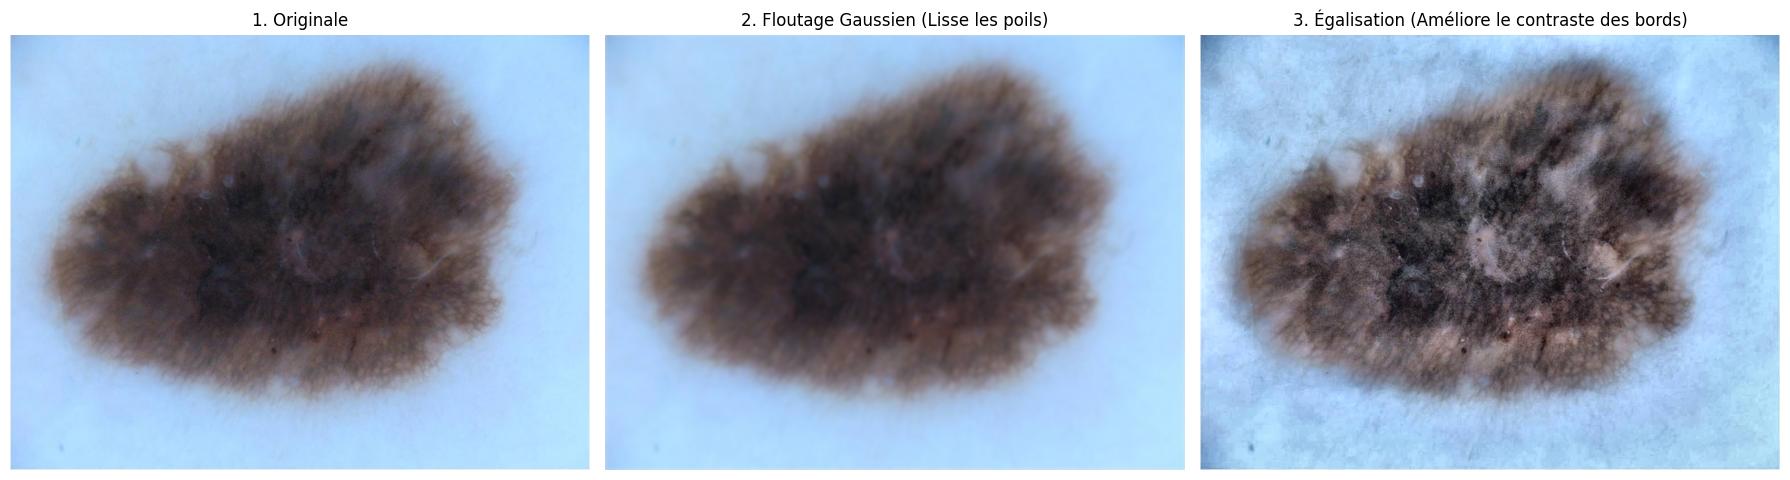

In [10]:
# 1. Charger une image d'exemple en niveaux de gris (plus facile pour l'égalisation)
data_dir = "../../Data/ISIC2018/task1/train/Training_Input"
image_files = sorted(glob.glob(os.path.join(data_dir, "*.jpg")))

if len(image_files) > 0:
    # Lire l'image avec OpenCV et la convertir en RGB
    img = cv2.imread(image_files[0])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # --- Transformation 1 : Floutage (Gaussian Blur) ---
    # Très utile sur ISIC pour faire disparaître les petits poils avant segmentation
    img_blurred = cv2.GaussianBlur(img_rgb, (15, 15), 0)
    
    # --- Transformation 2 : Égalisation d'histogramme (CLAHE) ---
    # On l'applique sur le canal L (Luminance) de l'espace colorimétrique LAB
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    img_equalized = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # Affichage
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Originale")
    axes[0].axis('off')
    
    axes[1].imshow(img_blurred)
    axes[1].set_title("2. Floutage Gaussien (Lisse les poils)")
    axes[1].axis('off')
    
    axes[2].imshow(img_equalized)
    axes[2].set_title("3. Égalisation (Améliore le contraste des bords)")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Veuillez d'abord télécharger les images dans le dossier ISIC2018.")


# Exemple de masque

In [11]:
def analyze_isic_dataset(data_dir):
    """
    Analyse basique du dataset ISIC 2018.
    Attends la structure officielle du challenge ISIC :
    data_dir/
      ├── images/ (Images .jpg)
      └── masks/ (Masques .png)
    """
    print(f"--- Analyse ISIC 2018 ---")
    
    splits = {
        "train": ("ISIC2018_Task1-2_Training_Input", "ISIC2018_Task1_Training_GroundTruth"),
        "validation": ("ISIC2018_Task1-2_Validation_Input", "ISIC2018_Task1_Validation_GroundTruth"),
        "test": ("ISIC2018_Task1-2_Test_Input", "ISIC2018_Task1_Test_GroundTruth")
    }
    
    total_images = 0
    image_files = []
    masks_dir = None
    
    for split_name, (img_folder, mask_folder) in splits.items():
        img_dir = os.path.join(data_dir, split_name, img_folder)
        if os.path.exists(img_dir):
            split_images = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
            count = len(split_images)
            print(f"Nombre d'images trouvées dans la partie '{split_name}' : {count}")
            total_images += count
            if count > 0 and len(image_files) == 0:
                # On garde les images et masques du premier split trouvé pour l'exemple visuel
                image_files = split_images
                masks_dir = os.path.join(data_dir, split_name, mask_folder)
        else:
            print(f"Nombre d'images trouvées dans la partie '{split_name}' : 0 (Dossier introuvable)")
            
    print(f"Total général d'images : {total_images}")
    
    if len(image_files) > 0:
        # Sélectionner la première image pour l'analyse
        img_path = image_files[0]
        # Dans ISIC, le masque a souvent le suffixe _segmentation
        base_name = os.path.basename(img_path).replace('.jpg', '')
        mask_path = os.path.join(masks_dir, f"{base_name}_segmentation.png")
        
        if os.path.exists(mask_path):
            img = Image.open(img_path)
            mask = Image.open(mask_path)
            
            print(f"Taille de l'image d'exemple : {img.size}")
            
            # Création de la figure pour visualiser
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
            
            ax1.imshow(img)
            ax1.set_title("Image Dermoscopique (Originale)")
            ax1.axis('off')
            
            ax2.imshow(mask, cmap='gray')
            ax2.set_title("Masque (Vérité Terrain)")
            ax2.axis('off')
            
            # Superposition pour voir la correspondance
            ax3.imshow(img)
            ax3.imshow(mask, cmap='jet', alpha=0.4) # alpha pour la transparence
            ax3.set_title("Superposition (Lésion ciblée)")
            ax3.axis('off')
            
            plt.suptitle(f"Exemple ISIC 2018: {base_name}")
            plt.tight_layout()
            plt.show()
            print("Visualisation affichée avec succès.")
        else:
            print(f"Masque introuvable pour {base_name}. Vérifiez le nommage (souvent _segmentation.png).")

if __name__ == "__main__":
    DATASET_PATH = "../../Data/ISIC2018/task1" 
    analyze_isic_dataset(DATASET_PATH)

--- Analyse ISIC 2018 ---
Nombre d'images trouvées dans la partie 'train' : 0 (Dossier introuvable)
Nombre d'images trouvées dans la partie 'validation' : 0 (Dossier introuvable)
Nombre d'images trouvées dans la partie 'test' : 0 (Dossier introuvable)
Total général d'images : 0


# Tailles des lesions dans les photos

In [12]:
# Catégoriser les images selon la taille du masque (Solution finale)
# 1. On récupère les chemins des masques d'entraînement
masks_dir = "../../Data/ISIC2018/task1/train/Training_GroundTruth"
mask_files = sorted(glob.glob(os.path.join(masks_dir, "*.png")))

tailles = []

print("Analyse en cours...")
for mask_path in mask_files:
    # Charger le masque en niveaux de gris
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if mask is not None:
        # Calculer l'aire
        total_pixels = mask.shape[0] * mask.shape[1]
        pixels_lesion = np.sum(mask > 0)
        pourcentage = (pixels_lesion / total_pixels) * 100
        
        # Définir la catégorie
        if pourcentage < 15:
            categorie = "Petite lésion (<15%)"
        elif pourcentage <= 40:
            categorie = "Lésion moyenne (15-40%)"
        else:
            categorie = "Grande lésion (>40%)"
            
        tailles.append(categorie)

# Transformer en DataFrame pour l'analyse
df_categories = pd.DataFrame(tailles, columns=["Catégorie"])

# 2. Comptage
comptage = df_categories["Catégorie"].value_counts()
print("--- Résultat du comptage ---")
print(comptage)

# 3. Affichage interactif avec Plotly
df_plot = comptage.reset_index()
df_plot.columns = ["Catégorie", "Nombre d'images"]

# Sauvegarder le comptage sous format CSV
comptage.to_csv("../../dashboard/ui/data_for_stats/lesion_sizes.csv")

fig = px.bar(
    df_plot,
    x="Catégorie",
    y="Nombre d'images",
    color="Catégorie",
    color_discrete_map={
        "Petite lésion (<15%)": "#4CAF50",
        "Lésion moyenne (15-40%)": "#FFC107",
        "Grande lésion (>40%)": "#F44336"
    },
    title="Répartition des images ISIC par taille de lésion",
    text="Nombre d'images"
)

fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title="Catégorie de taille",
    yaxis_title="Nombre d'images",
    showlegend=False,
    title_x=0.5,
    height=500
)

fig.show()

Analyse en cours...
--- Résultat du comptage ---
Catégorie
Petite lésion (<15%)       1354
Lésion moyenne (15-40%)     792
Grande lésion (>40%)        448
Name: count, dtype: int64


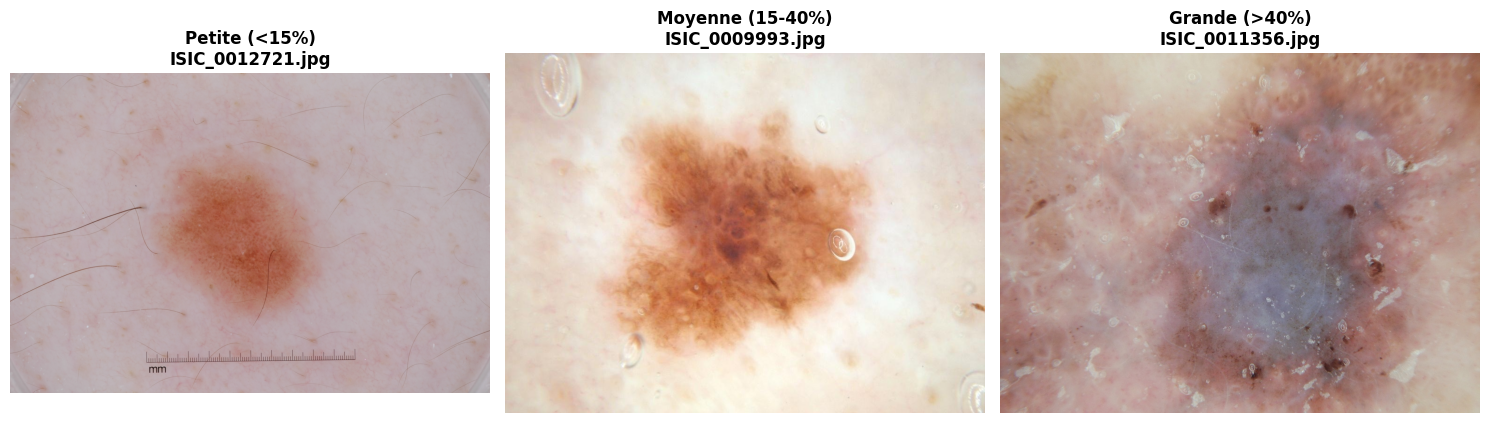

In [13]:
# Affichage d'une image de chaque type
# Chemins
masks_dir = "../../Data/ISIC2018/task1/train/Training_GroundTruth"
images_dir = "../../Data/ISIC2018/task1/train/Training_Input"

# Dictionnaire pour stocker nos trois championnes
trouves = {"Petite": None, "Moyenne": None, "Grande": None}

# On cherche une image pour chaque catégorie
for mask_file in os.listdir(masks_dir):
    if not mask_file.endswith(".png"): continue
    
    # Si on a trouvé les 3, on arrête de chercher
    if all(trouves.values()): break
        
    mask_path = os.path.join(masks_dir, mask_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if mask is not None:
        pourcentage = (np.sum(mask > 0) / (mask.shape[0] * mask.shape[1])) * 100
        
        # Le nom de l'image originale correspond au nom du masque
        # ex: ISIC_0000000_segmentation.png -> ISIC_0000000.jpg
        image_name = mask_file.replace("_segmentation.png", ".jpg")
        
        # On assigne la première image qui matche la condition
        if pourcentage < 15 and trouves["Petite"] is None:
            trouves["Petite"] = image_name
        elif 15 <= pourcentage <= 40 and trouves["Moyenne"] is None:
            trouves["Moyenne"] = image_name
        elif pourcentage > 40 and trouves["Grande"] is None:
            trouves["Grande"] = image_name

# --- Affichage ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titres = ["Petite (<15%)", "Moyenne (15-40%)", "Grande (>40%)"]

for ax, (cat, img_name), titre in zip(axes, trouves.items(), titres):
    if img_name:
        img_path = os.path.join(images_dir, img_name)
        # On lit l'image en couleurs (RGB) pour l'affichage
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{titre}\n{img_name}", fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


# Résolutions des images

In [14]:
# Chemin vers les images
images_dir = "../../Data/ISIC2018/task1/train/Training_Input"
image_files = glob.glob(os.path.join(images_dir, "*.jpg"))

largeurs = []
hauteurs = []

print(f"Analyse des résolutions pour {len(image_files)} images en cours...")

for img_path in image_files:
    # On utilise PIL pour lire uniquement les métadonnées (ultra rapide)
    with Image.open(img_path) as img:
        largeur, hauteur = img.size
        largeurs.append(largeur)
        hauteurs.append(hauteur)

df_res = pd.DataFrame({"Largeur": largeurs, "Hauteur": hauteurs})
# Sauvegarder les dimensions Largeur/Hauteur de toutes les images
df_res.to_csv("../../dashboard/ui/data_for_stats/image_resolutions.csv", index=False)

# 1. Affichage des statistiques textuelles
print("\n--- Statistiques des résolutions ---")
print(f"Résolution minimale : {df_res['Largeur'].min()} x {df_res['Hauteur'].min()} pixels")
print(f"Résolution maximale : {df_res['Largeur'].max()} x {df_res['Hauteur'].max()} pixels")
print(f"Résolution moyenne  : {int(df_res['Largeur'].mean())} x {int(df_res['Hauteur'].mean())} pixels")

# 2. Affichage interactif avec Plotly (Nuage de points / Scatter plot)
fig = px.scatter(
    df_res,
    x="Largeur",
    y="Hauteur",
    opacity=0.4,
    title="Distribution des résolutions d'images (ISIC 2018)"
)

fig.update_traces(
    marker=dict(
        size=8,
        color="#2196F3",
        line=dict(width=0.5, color="black")
    )
)

fig.update_layout(
    xaxis_title="Largeur (pixels)",
    yaxis_title="Hauteur (pixels)",
    title_x=0.5,
    height=600
)

fig.show()


Analyse des résolutions pour 2594 images en cours...

--- Statistiques des résolutions ---
Résolution minimale : 576 x 540 pixels
Résolution maximale : 6748 x 4499 pixels
Résolution moyenne  : 3188 x 2166 pixels


# Analyse métier

## etude croisée catégories images train2018 basée sur les truth2017

### trainset

In [15]:
# 1. On liste toutes les images du Train Set de la Tâche 1 de 2018 (dossier local)
train_dir = "../../Data/ISIC2018/task1/train/Training_Input"
image_files = glob.glob(os.path.join(train_dir, "*.jpg"))

train_images_ids = []
for filepath in image_files:
    img_id = os.path.basename(filepath).replace(".jpg", "")
    train_images_ids.append(img_id)

df_train_task1 = pd.DataFrame({"image_id": train_images_ids})
print(f"✅ Lues : {len(df_train_task1)} images dans le Train Set 2018 (Tâche 1).")

# 2. On charge les fichiers "Ground Truth" de 2017 (Train, Val, Test) pour retrouver les métadonnées
path_2017 = "../../Data/ISIC2017/task3/"
df_2017_train = pd.read_csv(os.path.join(path_2017, "train_truth/ISIC-2017_Training_Part3_GroundTruth.csv"))
df_2017_val = pd.read_csv(os.path.join(path_2017, "validation_truth/ISIC-2017_Validation_Part3_GroundTruth.csv"))
df_2017_test = pd.read_csv(os.path.join(path_2017, "test_truth/ISIC-2017_Test_v2_Part3_GroundTruth.csv"))

# On regroupe toutes les vérités terrain 2017 pour maximiser le croisement
df_2017_all = pd.concat([df_2017_train, df_2017_val, df_2017_test], ignore_index=True)

# 3. LE CROISEMENT !
df_merged = pd.merge(df_train_task1, df_2017_all, on="image_id", how="inner")
print(f"🎉 Succès ! Nous avons retrouvé la maladie pour {len(df_merged)} images du Train Set 2018 (soit {len(df_merged)/len(df_train_task1)*100:.1f}%) !")

# 4. En 2017, si ce n'est pas un Mélanome (1.0) ou une Kératose (1.0), on labelise comme quoi la lesion n'est catégorisée
def get_disease(row):
    if row['melanoma'] == 1.0:
        return 'Mélanome (Cancer)'
    elif row['seborrheic_keratosis'] == 1.0:
        return 'Kératose (Bénin)'
    else:
        return 'Non catégorisée'

df_merged['Maladie'] = df_merged.apply(get_disease, axis=1)

# 5. Création du graphique d'Analyse Métier avec Plotly
comptage_maladies = df_merged['Maladie'].value_counts().reset_index()
comptage_maladies.columns = ["Maladie", "Nombre d'images"]
# Sauvegarder les comptages par maladie
comptage_maladies.to_csv("../../dashboard/ui/data_for_stats/pathology_distribution_train.csv", index=False)

fig = px.bar(
    comptage_maladies,
    x="Maladie",
    y="Nombre d'images",
    color="Maladie",
    color_discrete_sequence=px.colors.qualitative.Set1,
    title="Répartition des maladies dans le Dataset d'Entraînement ISIC 2018 (Tâche 1)",
    text="Nombre d'images"
)

fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title="Type de Lésion",
    yaxis_title="Nombre d'images",
    showlegend=False,
    title_x=0.5,
    height=500
)

fig.show()


✅ Lues : 2594 images dans le Train Set 2018 (Tâche 1).
🎉 Succès ! Nous avons retrouvé la maladie pour 2450 images du Train Set 2018 (soit 94.4%) !


### testset

In [16]:
# 1. On liste toutes les images du Test Set de la Tâche 1 de 2018 (dossier local)
test_dir = "../../Data/ISIC2018/task1/test/Test_Input"
image_files = glob.glob(os.path.join(test_dir, "*.jpg"))

test_images_ids = []
for filepath in image_files:
    img_id = os.path.basename(filepath).replace(".jpg", "")
    test_images_ids.append(img_id)

df_test_task1 = pd.DataFrame({"image_id": test_images_ids})
print(f"✅ Lues : {len(df_test_task1)} images dans le Test Set 2018 (Tâche 1).")

# 2. On charge les fichiers "Ground Truth" de 2017 (Train, Val, Test) pour tenter le croisement
path_2017 = "../../Data/ISIC2017/task3/"
df_2017_train = pd.read_csv(os.path.join(path_2017, "train_truth/ISIC-2017_Training_Part3_GroundTruth.csv"))
df_2017_val = pd.read_csv(os.path.join(path_2017, "validation_truth/ISIC-2017_Validation_Part3_GroundTruth.csv"))
df_2017_test = pd.read_csv(os.path.join(path_2017, "test_truth/ISIC-2017_Test_v2_Part3_GroundTruth.csv"))

df_2017_all = pd.concat([df_2017_train, df_2017_val, df_2017_test], ignore_index=True)

# 3. LE CROISEMENT !
df_merged = pd.merge(df_test_task1, df_2017_all, on="image_id", how="inner")
print(f"🔍 Résultat du croisement : {len(df_merged)} correspondances trouvées sur {len(df_test_task1)} images ({len(df_merged)/len(df_test_task1)*100:.1f}%).")

if len(df_merged) == 0:
    print("❌ CONCLUSION : Les données de test de la tâche 1 d'ISIC 2018 sont entièrement ANONYMISÉES. Les identifiants ont été modifiés pour empêcher le croisement direct avec les diagnostics cliniques de 2017.")
else:
    # 4. En 2017, si ce n'est pas un Mélanome (1.0) ou une Kératose (1.0), on labelise comme quoi la lesion n'est catégorisée
    def get_disease(row):
        if row['melanoma'] == 1.0:
            return 'Mélanome (Cancer)'
        elif row['seborrheic_keratosis'] == 1.0:
            return 'Kératose (Bénin)'
        else:
            return 'Non catégorisée'

    df_merged['Maladie'] = df_merged.apply(get_disease, axis=1)

    # 5. Création du graphique d'Analyse Métier avec Plotly
    comptage_maladies = df_merged['Maladie'].value_counts().reset_index()
    comptage_maladies.columns = ["Maladie", "Nombre d'images"]

    fig = px.bar(
        comptage_maladies,
        x="Maladie",
        y="Nombre d'images",
        color="Maladie",
        color_discrete_sequence=px.colors.qualitative.Set1,
        title="Répartition des maladies dans le Dataset de Test ISIC 2018 (Tâche 1)",
        text="Nombre d'images"
)

    fig.update_traces(textposition='outside')
    fig.update_layout(
        xaxis_title="Type de Lésion",
        yaxis_title="Nombre d'images",
        showlegend=False,
        title_x=0.5,
        height=500
    )

    fig.show()

✅ Lues : 1000 images dans le Test Set 2018 (Tâche 1).
🔍 Résultat du croisement : 0 correspondances trouvées sur 1000 images (0.0%).
❌ CONCLUSION : Les données de test de la tâche 1 d'ISIC 2018 sont entièrement ANONYMISÉES. Les identifiants ont été modifiés pour empêcher le croisement direct avec les diagnostics cliniques de 2017.
